<a href="https://colab.research.google.com/github/yutiwii/KAL/blob/main/250411100125_Azzahro_Ayu_Pratiwi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

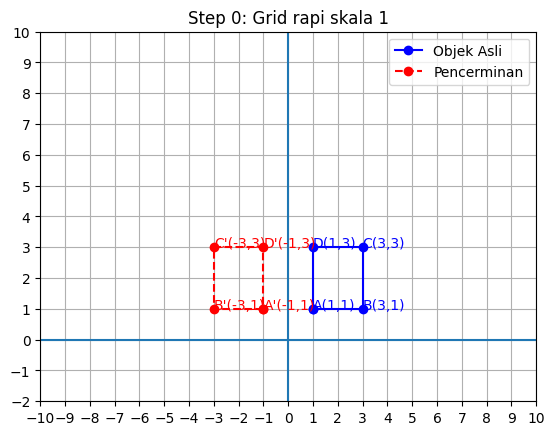

In [2]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import numpy as np

# ======================
# TITIK AWAL (Kuadran 1)
# ======================
points = [(1,1), (3,1), (3,3), (1,3)]
labels = ['A','B','C','D']

# ======================
# TRANSFORMASI
# ======================
def translasi(p, dx):
    return [(x+dx, y) for x, y in p]

def refleksi_y(p):
    return [(-x, y) for x, y in p]

# ======================
# GENERATE STEP GERAK
# ======================
steps_obj = []
steps_cermin = []

current = points.copy()

for i in range(6):
    steps_obj.append(current.copy())
    steps_cermin.append(refleksi_y(current))
    current = translasi(current, 1)

# ======================
# PLOT
# ======================
fig, ax = plt.subplots()

def update(frame):
    ax.clear()

    ax.set_xlim(-10, 10)
    ax.set_ylim(-2, 10)

    ax.set_xticks(np.arange(-10, 11, 1))  # x: -10 sampai 10, selisih 1
    ax.set_yticks(np.arange(-2, 11, 1))   # y: -2 sampai 10, selisih 1

    ax.grid(True)

    # sumbu
    ax.axhline(0)
    ax.axvline(0)

    obj = steps_obj[frame]
    cermin = steps_cermin[frame]

    obj_closed = obj + [obj[0]]
    cermin_closed = cermin + [cermin[0]]

    # objek asli
    x1 = [p[0] for p in obj_closed]
    y1 = [p[1] for p in obj_closed]
    ax.plot(x1, y1, 'bo-', label='Objek Asli')

    # hasil cermin
    x2 = [p[0] for p in cermin_closed]
    y2 = [p[1] for p in cermin_closed]
    ax.plot(x2, y2, 'ro--', label='Pencerminan')

    # label koordinat
    for i, (x, y) in enumerate(obj):
        ax.text(x, y, f"{labels[i]}({x},{y})", color='blue')

    for i, (x, y) in enumerate(cermin):
        ax.text(x, y, f"{labels[i]}'({x},{y})", color='red')

    ax.set_title(f"Step {frame}: Grid rapi skala 1")
    ax.legend()

# animasi
ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(steps_obj),
    interval=1000,
    repeat=False
)

HTML(ani.to_jshtml())